In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential
from sklearn.model_selection import train_test_split

2026-05-06 18:00:08.312494: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:467] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1778090408.657029      57 cuda_dnn.cc:8579] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1778090408.756733      57 cuda_blas.cc:1407] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
W0000 00:00:1778090409.620096      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778090409.620138      57 computation_placer.cc:177] computation placer already registered. Please check linkage and avoid linking the same target more than once.
W0000 00:00:1778090409.620141      57 computation_placer.cc:177] computation placer alr

In [2]:
df_test = pd.read_csv("/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_test.csv")
df_train = pd.read_csv("/kaggle/input/datasets/organizations/zalando-research/fashionmnist/fashion-mnist_train.csv")

In [3]:
test = np.array(df_test,dtype="float32")
train = np.array(df_train,dtype="float32")

x_train = train[:,1:]

y_train = train[:,0]

x_test= test[:,1:]

y_test=test[:,0]

x_train = x_train.reshape(-1, 28, 28, 1)
x_test = x_test.reshape(-1, 28, 28, 1)

In [4]:
x_train,x_validate,y_train,y_validate = train_test_split(x_train,y_train,test_size = 0.2,random_state = 12345)

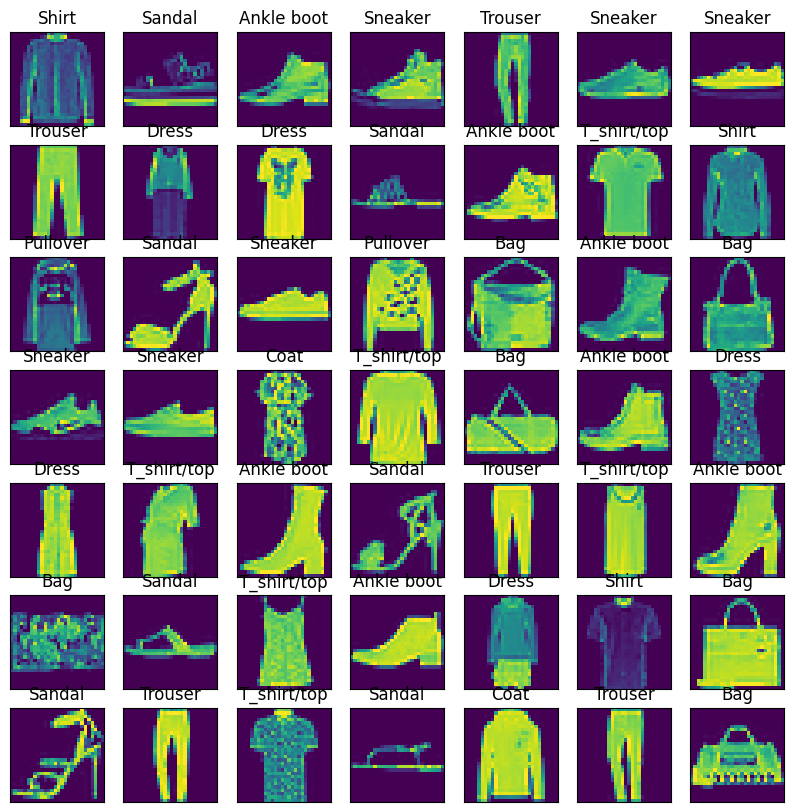

In [5]:
class_names = ['T_shirt/top', 'Trouser', 'Pullover', 'Dress', 'Coat', 
               'Sandal', 'Shirt', 'Sneaker', 'Bag', 'Ankle boot']
plt.figure(figsize=(10, 10))
for i in range(49):
    plt.subplot(7, 7, i + 1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[i].reshape((28,28)))
    label_index = int(y_train[i])
    plt.title(class_names[label_index])
plt.show()

In [10]:
imageSize = 28
batchSize = 16
resize_rescale = Sequential([
    layers.Resizing(imageSize, imageSize),
    layers.Rescaling(1.0/imageSize)
])

data_aug = Sequential([
    layers.RandomFlip(mode="horizontal_and_vertical"),
    layers.RandomRotation(factor=0.3)
])

In [113]:
model = Sequential([
     layers.Input(shape=(28,28,1)),
    resize_rescale,
    data_aug,
    layers.Conv2D(filters = 64, kernel_size= 5, activation = "relu",padding='same'),
    layers.MaxPooling2D(pool_size=3),
    layers.Conv2D(filters = 128, kernel_size= 7, activation = "relu",padding='same'),
    layers.MaxPooling2D(pool_size=3),
    layers.Conv2D(filters = 32, kernel_size= 3, activation = "relu",padding='same'),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(128,activation="relu"),
    layers.Dense(32,activation="relu"),
    layers.Dense(10,activation="softmax")
])

In [114]:
model.compile(
    loss = ["sparse_categorical_crossentropy"],
    optimizer = "adam",
    metrics = ["accuracy"],
)

In [115]:
model.summary()

Model: "sequential_18"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ sequential_3 (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ sequential_4 (Sequential)       │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_36 (Conv2D)              │ (None, 28, 28, 64)     │         1,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_34 (MaxPooling2D) │ (None, 9, 9, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_37 (Conv2D)              │ (None, 9, 9, 128)      │       401,536 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_35 (MaxPooling2D) │ (None, 3, 3, 128)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_38 (Conv2D)              │ (None, 3, 3, 32)       │        36,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_14 (Dropout)            │ (None, 3, 3, 32)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_14 (Flatten)            │ (None, 288)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_40 (Dense)                │ (None, 128)            │        36,992 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_41 (Dense)                │ (None, 32)             │         4,128 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_42 (Dense)                │ (None, 10)             │           330 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 481,546 (1.84 MB)

 Trainable params: 481,546 (1.84 MB)

 Non-trainable params: 0 (0.00 B)

In [116]:
history = model.fit(x_train,y_train,epochs=40, batch_size = 512)

Epoch 1/40


E0000 00:00:1778092100.179602      57 meta_optimizer.cc:967] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape inStatefulPartitionedCall/sequential_18_1/dropout_14_1/stateless_dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


94/94 ━━━━━━━━━━━━━━━━━━━━ 4s 19ms/step - accuracy: 0.3025 - loss: 1.8790
Epoch 2/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.6441 - loss: 0.9607
Epoch 3/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.6897 - loss: 0.8154
Epoch 4/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7325 - loss: 0.7175
Epoch 5/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7504 - loss: 0.6697
Epoch 6/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7724 - loss: 0.6231
Epoch 7/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - accuracy: 0.7840 - loss: 0.5989
Epoch 8/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.7917 - loss: 0.5756
Epoch 9/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 16ms/step - accuracy: 0.8021 - loss: 0.5507
Epoch 10/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8086 - loss: 0.5231
Epoch 11/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8159 - loss: 0.5062
Epoch 12/40
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 15ms/step - accuracy: 0.8214 - l

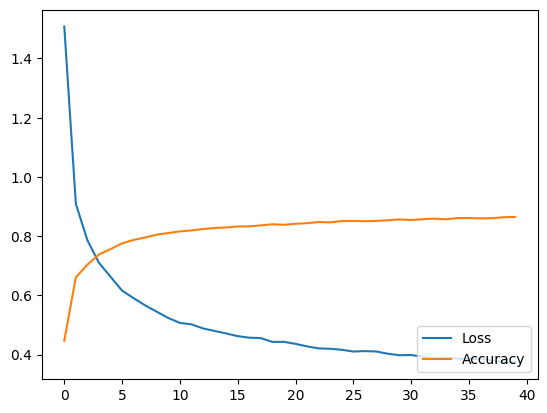

In [118]:
plt.plot(history.history["loss"],label = "Loss")
plt.plot(history.history["accuracy"], label = "Accuracy")
plt.legend(loc = "lower right")

In [119]:
scores = model.evaluate(x_validate,y_validate)

375/375 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - accuracy: 0.8569 - loss: 0.4040


In [120]:
scores

[0.4056031107902527, 0.8572499752044678]

In [121]:
y_pred_t = model.predict(x_test)

y_pred = np.argmax(y_pred_t, axis=1)

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step


In [122]:
y_pred.shape, y_test.shape

((10000,), (10000,))

              precision    recall  f1-score   support

         0.0       0.85      0.74      0.79      1000
         1.0       0.98      0.97      0.97      1000
         2.0       0.87      0.72      0.79      1000
         3.0       0.79      0.90      0.84      1000
         4.0       0.76      0.81      0.79      1000
         5.0       0.95      0.97      0.96      1000
         6.0       0.63      0.70      0.66      1000
         7.0       0.88      0.97      0.92      1000
         8.0       0.93      0.91      0.92      1000
         9.0       0.98      0.88      0.93      1000

    accuracy                           0.86     10000
   macro avg       0.86      0.86      0.86     10000
weighted avg       0.86      0.86      0.86     10000



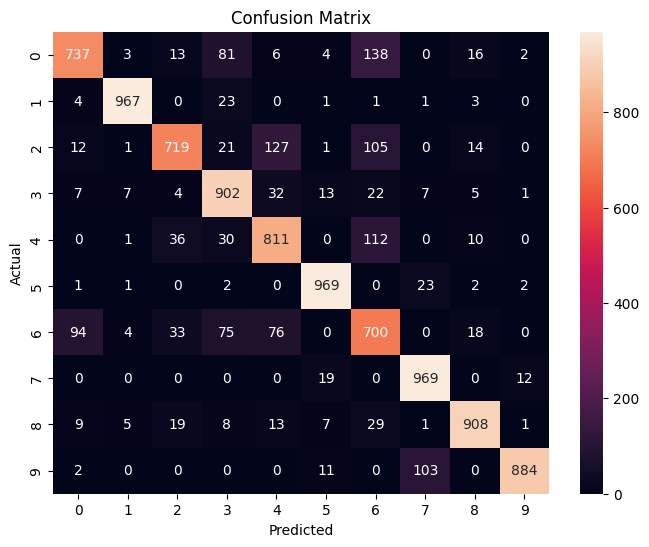

In [123]:
from sklearn.metrics import confusion_matrix,classification_report
import seaborn as sns
import numpy as np

cm = confusion_matrix(y_test, y_pred)
cr = classification_report(y_test,y_pred)

print(cr)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=True, fmt='d')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

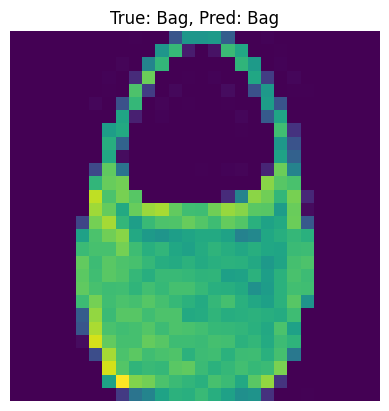

In [124]:
plt.imshow(x_test[2000].reshape(28,28))
plt.title(f"True: {class_names[int(y_test[2000])]}, Pred: {class_names[int(y_pred[2000])]}")
plt.axis('off')
plt.show()
